# Recap overview

All the recap lists of the blog side by side:

- **Monthly** (`top-of-the-month.md`, top 15 per month, only valid recaps with real releases)
- **Yearly** (`top-25-recap-<YEAR>.md`, ranked top 25)
- **Lifetime** (`top-25-lifetime.md`, unranked top 25 of all time)

Genres and pick stars come from the weekly posts, wherever a recap entry can be found there.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from music_stats import (
    load_lifetime, load_recaps, load_releases, load_yearly_recaps, name_key,
)

TOP_N = 15

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

monthly = pd.DataFrame(load_recaps())
yearly = pd.DataFrame(load_yearly_recaps())
lifetime = pd.DataFrame(load_lifetime())
posts = pd.DataFrame(load_releases())
posts["year"] = posts["week"].str[:4]

monthly["artist"] = monthly["name"].str.partition(" - ")[0]
yearly["artist"] = yearly["name"].str.partition(" - ")[0]
lifetime["artist"] = lifetime["name"].str.partition(" - ")[0]

# Find recap entries in the weekly posts: same month (monthly), same year (yearly) or anywhere (lifetime).
def find(frame, scope):
    index = {}
    for r in posts.to_dict("records"):
        index.setdefault((r[scope] if scope else None, name_key(r["name"])), r)
    keys = [(row[scope] if scope else None, name_key(row["name"])) for row in frame.to_dict("records")]
    return [index.get(k) for k in keys]

for frame, scope in ((monthly, "month"), (yearly, "year"), (lifetime, None)):
    hits = find(frame, scope)
    frame["found"] = [h is not None for h in hits]
    frame["tier"] = [h["tier"] if h else None for h in hits]
    frame["genres"] = [h["genres"] if h else [] for h in hits]

## At a glance

In [2]:
glance = pd.DataFrame(
    {
        "lists": [monthly["month"].nunique(), yearly["year"].nunique(), 1 if len(lifetime) else 0],
        "entries": [len(monthly), len(yearly), len(lifetime)],
        "found in weekly posts": [monthly["found"].sum(), yearly["found"].sum(), lifetime["found"].sum()],
    },
    index=["monthly", "yearly", "lifetime"],
)
display(glance)

,lists,entries,found in weekly posts
monthly,9,135,130
yearly,1,25,21
lifetime,1,25,1


## Monthly recaps

The number one of every month, and how many entries each recap has.

In [3]:
winners = monthly[monthly["rank"] == 1].set_index("month")[["name", "tier"]]
display(winners.join(monthly.groupby("month").size().rename("entries")))

,name,tier,entries
month,,,
2026-01,"Pedrito Martínez, Antonio Sánchez, Michael League - Elipsis",NaN,15
2026-02,Abronia - Shapes Unravel,top,15
2026-03,Boys Go To Jupiter - Now You're A Circle,NaN,15
2026-04,Angine de Poitrine - Vol. II,top,15
2026-05,Kokomo - Whip,top,15
2026-06,American Cream Band - Twin,pick,15
2026-07,Tricky - Different When It's Silent,top,15
2026-08,Russian Circles - Nine,pick,15
2026-09,Agnes Obel - The Meaning of Flowers,pick,15


## Yearly recaps

In [4]:
for year, frame in yearly.groupby("year"):
    print(f"Top 25 of {year}")
    display(frame.sort_values("rank").assign(genres=frame["genres"].str.join(", "))
            [["rank", "name", "tier", "genres"]].set_index("rank"))

Top 25 of 2025


,name,tier,genres
rank,,,
1,Turnstile - Never Enough,top,"Hardcore Punk, Post Punk, Shoegaze, Alternative Rock, Synth Pop"
2,Benjamin Booker - Lower,none,
3,Miley Cyrus - Something Beautiful,top,"Introspective Pop, Alternative Pop, Pop Rock"
4,Pothamus - Abur,none,
5,Messa - The Spin,none,
6,Anna von Hausswolff - Iconoclasts,top,"Alternative Pop, Indie Pop, Drone, Dark Wave, Art Pop, Avant-Garde Pop, Jazz..."
7,The Callous Daoboys - I don't want to see you in Heaven,none,
8,Between The Buried And Me - The Blue Nowhere,top,"Progressive Metal, Experimental Metal"
9,Deadguy - Near Death Travel Service,NaN,


### How much of the year came from the monthly recaps?

Share of each yearly top 25 that already appeared in a monthly recap of that year.

In [5]:
rows = []
for year, frame in yearly.groupby("year"):
    in_monthly = set(monthly[monthly["month"].str.startswith(year)]["name"].map(name_key))
    hits = frame["name"].map(name_key).isin(in_monthly)
    rows.append({"year": year, "entries": len(frame), "also in a monthly recap": int(hits.sum()),
                 "monthly recaps that year": monthly[monthly["month"].str.startswith(year)]["month"].nunique()})
display(pd.DataFrame(rows).set_index("year"))

,entries,also in a monthly recap,monthly recaps that year
year,,,
2025,25,0,0


## Lifetime recap

The all-time list, in the order it is shown on the page.

In [6]:
display(lifetime.assign(genres=lifetime["genres"].str.join(", "))[["position", "name", "genres"]].set_index("position"))
display(lifetime["artist"].value_counts().loc[lambda s: s > 1].rename("entries"))

,name,genres
position,,
1,The Beatles - Sgt. Pepper's Lonely Hearts Club Band,
2,Wire - Chairs Missing,
3,Fleetwood Mac - Rumours,
4,Jefferson Airplane - Surrealistic Pillow,
5,Kate Bush - The Kick Inside,
6,Pink Floyd - Wish You Were Here,
7,The B-52's - Wild Planet,
8,The Clash - London Calling,
9,Refused - The Shape of Punk to Come,


Series([], Name: entries, dtype: int64)

## Across all recaps

### Artists in more than one recap type

In [7]:
spread = pd.concat([
    monthly.assign(recap="monthly")[["artist", "recap"]],
    yearly.assign(recap="yearly")[["artist", "recap"]],
    lifetime.assign(recap="lifetime")[["artist", "recap"]],
])
by_artist = spread.groupby("artist")["recap"].agg(lambda s: sorted(set(s)))
multi = by_artist[by_artist.str.len() > 1]
display(multi.str.join(", ").rename("recaps"))

artist
Arcade Fire     lifetime, yearly
Muse           lifetime, monthly
Name: recaps, dtype: object

### Artists with the most recap entries

In [8]:
counts = spread["artist"].value_counts().head(TOP_N)
display(counts.rename("entries"))

artist
Converge                                             2
Muse                                                 2
Arcade Fire                                          2
Pedrito Martínez, Antonio Sánchez, Michael League    1
Hér                                                  1
MØL                                                  1
Jazzpospolita                                        1
Poppy                                                1
Under                                                1
Gavran                                               1
Summer of Hate                                       1
Perfect                                              1
Orchestra of the Upper Atmosphere                    1
Plantoid                                             1
Christian Löffler                                    1
Name: entries, dtype: int64

### Genres per recap type

Only entries that could be found in the weekly posts carry genres, so the lifetime list is covered the least.

,monthly,yearly,lifetime,total
genres,,,,
Psychedelic Rock,30,0,0,30
Krautrock,25,0,0,25
Post Punk,22,1,0,23
Progressive Rock,22,1,0,23
Art Rock,22,0,0,22
Trip Hop,18,1,0,19
Avant-Garde Rock,15,1,0,16
Indie Rock,15,1,0,16
Post Rock,15,0,0,15


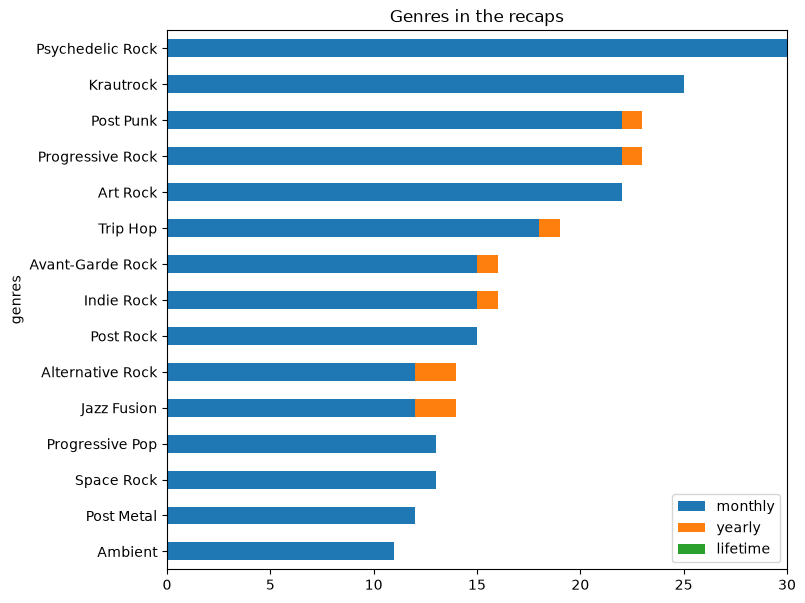

In [9]:
def genre_counts(frame):
    return frame.explode("genres")["genres"].dropna().value_counts()

per_type = pd.DataFrame({
    "monthly": genre_counts(monthly), "yearly": genre_counts(yearly), "lifetime": genre_counts(lifetime),
}).fillna(0).astype(int)
per_type["total"] = per_type.sum(axis=1)
top = per_type.sort_values("total", ascending=False).head(TOP_N)
display(top)
top.drop(columns="total")[::-1].plot.barh(stacked=True, figsize=(8, 0.4 * len(top) + 1), title="Genres in the recaps")
plt.show()